In [1]:
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import intake
mpl.rcParams['figure.dpi'] = 72

In [2]:
# source = "scream"
# source = "nicam_gl11"
# source = "um_glm_n2560_RAL3p3"
# source = "icon_d3hp003"
# source = "ifs_tco3999_rcbmf"
# source = "casesm2_10km_nocumulus"
source = "IMERGv7"

# MCS masks
root_dir = "/pscratch/sd/w/wcmca1/hackathon/mcs_masks/"
in_zarr = f"{root_dir}{source}_mcs_masks_hp8.zarr"
in_zarr

# # Combined all feature masks
# root_dir = "/pscratch/sd/w/wcmca1/hackathon/all_masks/"
# in_zarr = f"{root_dir}{source}_allmasks_hp8_v1.zarr"
# in_zarr

'/pscratch/sd/w/wcmca1/hackathon/mcs_masks/IMERGv7_mcs_masks_hp8.zarr'

In [3]:
ds = xr.open_zarr(in_zarr, consolidated=True)
ds

<xarray.Dataset> Size: 31MB
Dimensions:   (time: 4, cell: 786432)
Coordinates:
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    crs       int64 8B ...
  * time      (time) datetime64[ns] 32B 2019-08-01 ... 2019-08-01T18:00:00
Data variables:
    ccs_mask  (time, cell) float32 13MB dask.array<chunksize=(4, 786432), meta=np.ndarray>
    mcs_mask  (time, cell) float32 13MB dask.array<chunksize=(4, 786432), meta=np.ndarray>
Attributes: (12/18)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Fri May 23 22:09:22 2025
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    processing_script:         make_mcs_swath_masks.py
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [4]:
ds.time[0:10]

<xarray.DataArray 'time' (time: 4)> Size: 32B
array(['2019-08-01T00:00:00.000000000', '2019-08-01T06:00:00.000000000',
       '2019-08-01T12:00:00.000000000', '2019-08-01T18:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    crs      int64 8B ...
  * time     (time) datetime64[ns] 32B 2019-08-01 ... 2019-08-01T18:00:00
Attributes:
    long_name:  Base time in Epoch

<Figure size 460.8x345.6 with 0 Axes>

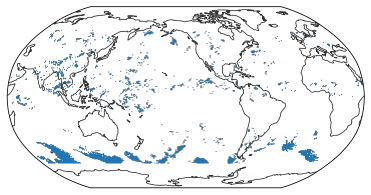

In [5]:
itime = 1
ccs_mask = ds.ccs_mask.isel(time=itime)
egh.healpix_show(ccs_mask.where(ccs_mask > 0), cmap='tab20')

<Figure size 460.8x345.6 with 0 Axes>

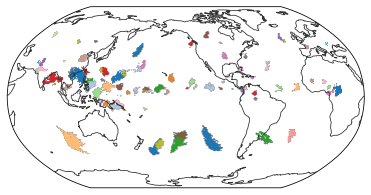

In [6]:
# itime = 1021
itime = 1
mcs_mask = ds.mcs_mask.isel(time=itime)
egh.healpix_show(mcs_mask.where(mcs_mask > 0), cmap='tab20')

In [6]:
sdate = '2020-03-01T00'
edate = '2020-03-31T23'

mcs_binary = ds.mcs_mask.sel(time=slice(sdate, edate)) > 0
mcs_count = mcs_binary.sum(dim='time')
nhours = ds.time.sel(time=slice(sdate, edate)).count()

mcs_freq = 100 * mcs_count / nhours

<Figure size 460.8x345.6 with 0 Axes>

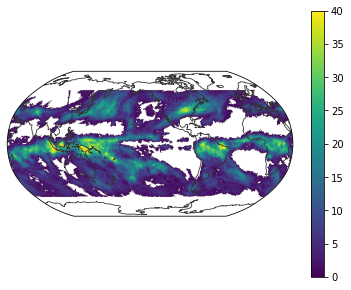

In [7]:
img = egh.healpix_show(mcs_freq.where(mcs_freq > 0), vmin=0, vmax=40)
plt.colorbar(img)

In [8]:
mcs_freq.max().values

array(55.64516129)